# 05 - Query Translation: Improving Retrieval Upstream

**Phase 5** of the RAG project. Rather than changing *how* we retrieve documents,
we change *what* we retrieve by transforming the user's question before hitting the vector store.

Five techniques are compared against the Phase 5 baseline (similarity search, mxbai-embed-large,
MRR=0.8667 on this benchmark):

1. **Multi-Query** - LLM generates N alternative phrasings, results are merged
2. **RAG Fusion** - same as multi-query but uses Reciprocal Rank Fusion (RRF) for merging
3. **HyDE** - LLM generates a hypothetical answer, its embedding is used for retrieval
4. **Step-Back** - LLM abstracts the query, both original and abstract retrieve docs
5. **Decomposition** - LLM splits the query into sub-questions, each retrieves independently

### Evaluated Metrics

Same IR metrics as Phase 4:
- **Precision@k** - fraction of top-k results that are relevant
- **Recall@k** - fraction of relevant docs found in top-k
- **MRR** - reciprocal rank of the first relevant result
- **nDCG@k** - ranking quality (accounts for position)
- **Latency** - total retrieval time including LLM calls (ms)
- **LLM calls** - number of additional LLM calls per query

---

## 0. Setup

In [1]:
import json
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion.loaders import load_documents_from_directory
from src.ingestion.cleaners import clean_corpus
from src.ingestion.chunkers import chunk_recursive
from src.embeddings.models import create_from_registry
from src.retrieval.dense import retrieve_dense
from src.chains.query_translation import (
    retrieve_multi_query,
    retrieve_rag_fusion,
    retrieve_hyde,
    retrieve_step_back,
    retrieve_decomposition,
)
from notebooks.utils.display import (
    display_strategy_comparison,
    display_category_breakdown,
    display_latency_comparison,
    display_radar_chart,
)
from notebooks.utils.metrics import (
    load_benchmark_questions,
    compute_retrieval_metrics,
    BenchmarkQuestion,
)

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)

print(f"Project root: {PROJECT_ROOT}")

Project root: /home/hunganh/Code/Python/course_qa_assist


## 1. Corpus Preparation

Same setup as Phase 4: filtered corpus (exclude `/python/integrations/`),
mxbai-embed-large, recursive chunking (1000/200).
This run yields **2,666 core docs** and **9,137 chunks**.
A separate ChromaDB collection is used to avoid conflicts with Phase 4.

In [2]:
# Load and clean
docs = load_documents_from_directory(str(PROJECT_ROOT / "data" / "lectures"))
cleaned_docs, _ = clean_corpus(docs, min_content_length=50)

# Filter: keep only core docs (exclude /python/integrations/ noise)
core_docs = [
    d for d in cleaned_docs
    if "/python/integrations/" not in d.metadata.get("source", "")
]
print(f"Corpus: {len(docs)} docs -> {len(cleaned_docs)} cleaned -> {len(core_docs)} core (filtered)")

# Chunk
result = chunk_recursive(core_docs, chunk_size=1000, chunk_overlap=200)
chunks = result.chunks
print(f"Chunked: {len(core_docs)} docs -> {len(chunks)} chunks")

Loaded 2703 document pages from /home/hunganh/Code/Python/course_qa_assist/data/lectures
Corpus: 2703 docs -> 2666 cleaned -> 2666 core (filtered)
Chunked: 2666 docs -> 9137 chunks


In [3]:
import chromadb
from langchain_chroma import Chroma

PERSIST_DIR = str(PROJECT_ROOT / "vectorstore" / "chroma_db")
COLLECTION = "query_translation_eval"
MODELS_YAML = str(PROJECT_ROOT / "configs" / "models.yaml")

# Embedding model
embeddings, emb_info = create_from_registry("mxbai_large", config_path=MODELS_YAML)
embeddings.embed_query("warmup")  # warmup
print(f"Embedding model: {emb_info.model_id} ({emb_info.dimensions}d)")

# ChromaDB index
client = chromadb.PersistentClient(path=PERSIST_DIR)
try:
    client.delete_collection(COLLECTION)
except Exception:
    pass

print(f"Indexing {len(chunks)} chunks into ChromaDB...")
start = time.perf_counter()
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    client=client,
    collection_name=COLLECTION,
)
index_time = time.perf_counter() - start
print(f"Indexed in {index_time:.1f}s ({vectorstore._collection.count()} chunks)")

Embedding model: mxbai-embed-large (1024d)
Indexing 9137 chunks into ChromaDB...
Indexed in 141.0s (9137 chunks)


In [4]:
# Load benchmark questions
questions = load_benchmark_questions(
    str(PROJECT_ROOT / "data" / "evaluation" / "benchmark_retrieval.json")
)

categories = {}
for q in questions:
    categories.setdefault(q.category, []).append(q)

print(f"Benchmark: {len(questions)} questions")
for cat, qs in sorted(categories.items()):
    print(f"  {cat}: {len(qs)} questions")

Benchmark: 5 questions
  methodology: 3 questions
  results: 2 questions


In [5]:
from langchain_ollama import ChatOllama

llm = ChatOllama(model="mistral:7b", temperature=0.3)

# Warmup LLM
_ = llm.invoke("Say 'ok'.")
print("LLM: mistral:7b (Ollama) - ready")

LLM: mistral:7b (Ollama) - ready


---
## 2. Baseline: Similarity Search

Re-run Phase 4 baseline on this collection for direct comparison.

In [6]:
K = 5

baseline_metrics = []
for q in questions:
    result = retrieve_dense(vectorstore, q.query, search_type="similarity", k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "similarity"
    m["llm_calls"] = 0
    baseline_metrics.append(m)

baseline_df = pd.DataFrame(baseline_metrics)
print("Baseline Similarity Search:")
print(f"  Precision@{K}: {baseline_df['precision_at_k'].mean():.4f}")
print(f"  Recall@{K}:    {baseline_df['recall_at_k'].mean():.4f}")
print(f"  MRR:           {baseline_df['mrr'].mean():.4f}")
print(f"  nDCG@{K}:      {baseline_df['ndcg_at_k'].mean():.4f}")
print(f"  Latency:       {baseline_df['latency_ms'].mean():.1f} ms")

Baseline Similarity Search:
  Precision@5: 0.7600
  Recall@5:    0.7600
  MRR:           0.8667
  nDCG@5:      0.7755
  Latency:       28.7 ms


---
## 3. Multi-Query

The LLM generates 4 alternative phrasings of each question.
Each variant retrieves k documents; results are merged and deduplicated.

Compared to Phase 4's multi-query: improved prompt focused on LangChain context.

In [7]:
from src.chains.query_translation import translate_multi_query

# Show an example of generated queries
example_q = questions[0]
variants = translate_multi_query(llm, example_q.query, n=4)
print(f"Original: {example_q.query}")
print("\nGenerated variants:")
for i, v in enumerate(variants, 1):
    print(f"  {i}. {v}")

Original: What are the primary characteristics and constraints of TinyML systems mentioned in the text?

Generated variants:
  1. 1. What are the key features and limitations of TinyML systems as discussed in the text?
  2. 2. Can you list the main traits and boundaries of TinyML systems according to the provided text?
  3. 3. Characteristics and restrictions of TinyML systems - text analysis
  4. 4. Identifying primary attributes and constraints in TinyML systems from the given text


In [8]:
print(f"Multi-Query benchmark ({len(questions)} questions, may take a few minutes)...\n")

mq_metrics = []
for i, q in enumerate(questions):
    result = retrieve_multi_query(llm, vectorstore, q.query, k=K, n_queries=4)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "multi_query"
    m["llm_calls"] = result.llm_calls
    mq_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

mq_df = pd.DataFrame(mq_metrics)
print(f"\nMulti-Query:")
print(f"  Precision@{K}: {mq_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {mq_df['mrr'].mean():.4f}")
print(f"  Latency:       {mq_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {mq_df['llm_calls'].mean():.0f}")

Multi-Query benchmark (5 questions, may take a few minutes)...

  5/5 done...

Multi-Query:
  Precision@5: 0.7200
  MRR:           0.8000
  Latency:       1882.0 ms
  LLM calls/q:   1


---
## 4. RAG Fusion

Same query variants as multi-query, but results are merged using
**Reciprocal Rank Fusion (RRF)**. Documents that appear across multiple
query variants get a boosted score proportional to their rank.

RRF formula: `score(doc) = sum(1 / (rank + k))` where k=60.

In [9]:
print(f"RAG Fusion benchmark ({len(questions)} questions)...\n")

rf_metrics = []
for i, q in enumerate(questions):
    result = retrieve_rag_fusion(llm, vectorstore, q.query, k=K, n_queries=4)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "rag_fusion"
    m["llm_calls"] = result.llm_calls
    rf_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

rf_df = pd.DataFrame(rf_metrics)
print(f"\nRAG Fusion:")
print(f"  Precision@{K}: {rf_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {rf_df['mrr'].mean():.4f}")
print(f"  Latency:       {rf_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {rf_df['llm_calls'].mean():.0f}")

RAG Fusion benchmark (5 questions)...

  5/5 done...

RAG Fusion:
  Precision@5: 0.8000
  MRR:           1.0000
  Latency:       1899.9 ms
  LLM calls/q:   1


---
## 5. HyDE (Hypothetical Document Embeddings)

Instead of embedding the question, the LLM generates a hypothetical answer
passage and that passage is embedded. Since answers and documents share
similar vocabulary, this can bridge the query-document semantic gap.

Example: "What is RAG?" -> LLM generates "RAG (Retrieval-Augmented Generation)
is a technique that..." -> the answer embedding is used for retrieval.

In [10]:
from src.chains.query_translation import generate_hyde_doc

# Show a HyDE-generated document
hyde_text = generate_hyde_doc(llm, questions[0].query)
print(f"Query: {questions[0].query}")
print(f"\nHyDE document:\n{hyde_text}")

Query: What are the primary characteristics and constraints of TinyML systems mentioned in the text?

HyDE document:
TinyML systems, as outlined in relevant literature, exhibit several primary characteristics, including minimal computational resources (CPU, memory, and power), small model size, and low-latency operation. The constraints associated with these systems include limited processing capabilities, stringent energy efficiency requirements, and the need for lightweight machine learning models that can be executed on resource-constrained devices such as microcontrollers or mobile phones without dedicated AI hardware. Furthermore, TinyML systems often face challenges in data collection and annotation due to the scarcity of labeled datasets suitable for training ultra-lightweight models.


In [11]:
print(f"HyDE benchmark ({len(questions)} questions)...\n")

hyde_metrics = []
for i, q in enumerate(questions):
    result = retrieve_hyde(llm, embeddings, vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "hyde"
    m["llm_calls"] = result.llm_calls
    hyde_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

hyde_df = pd.DataFrame(hyde_metrics)
print(f"\nHyDE:")
print(f"  Precision@{K}: {hyde_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {hyde_df['mrr'].mean():.4f}")
print(f"  Latency:       {hyde_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {hyde_df['llm_calls'].mean():.0f}")

HyDE benchmark (5 questions)...

  5/5 done...

HyDE:
  Precision@5: 0.8000
  MRR:           0.8667
  Latency:       2745.8 ms
  LLM calls/q:   1


---
## 6. Step-Back Prompting

Some queries are too specific. The vector store may not have a chunk about
"What is the default chunk_overlap?" but it does have the RecursiveCharacterTextSplitter docs.

Step-back generates a more abstract version of the question, retrieves with both,
then merges results.

In [12]:
from src.chains.query_translation import translate_step_back

# Show step-back on a methodology query
tech_q = [q for q in questions if q.category == "methodology"][0]
abstract = translate_step_back(llm, tech_q.query)
print(f"Original:  {tech_q.query}")
print(f"Step-back: {abstract}")

Original:  What are the primary characteristics and constraints of TinyML systems mentioned in the text?
Step-back: What are the key features and limitations of micro-embedded AI systems, as discussed in various contexts?


In [13]:
print(f"Step-Back benchmark ({len(questions)} questions)...\n")

sb_metrics = []
for i, q in enumerate(questions):
    result = retrieve_step_back(llm, vectorstore, q.query, k=K)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "step_back"
    m["llm_calls"] = result.llm_calls
    sb_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

sb_df = pd.DataFrame(sb_metrics)
print(f"\nStep-Back:")
print(f"  Precision@{K}: {sb_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {sb_df['mrr'].mean():.4f}")
print(f"  Latency:       {sb_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {sb_df['llm_calls'].mean():.0f}")

Step-Back benchmark (5 questions)...

  5/5 done...

Step-Back:
  Precision@5: 0.7600
  MRR:           0.8667
  Latency:       721.4 ms
  LLM calls/q:   1


---
## 7. Query Decomposition

Complex multi-part questions are split into 3 simpler sub-questions.
Each sub-question retrieves independently, results are merged and deduplicated.

This addresses queries like "Compare ChromaDB vs FAISS" where multiple
topics need to be retrieved separately.

In [14]:
from src.chains.query_translation import translate_decompose

# Show decomposition on a results query
howto_q = [q for q in questions if q.category == "results"][0]
sub_qs = translate_decompose(llm, howto_q.query, n=3)
print(f"Original: {howto_q.query}")
print("\nSub-questions:")
for i, sq in enumerate(sub_qs, 1):
    print(f"  {i}. {sq}")

Original: How do large-scale ML systems manage coordination strategies for real-time processing?

Sub-questions:
  1. 1. What are large-scale Machine Learning (ML) systems?
  2. 2. What are the coordination strategies used for real-time processing in these systems?
  3. 3. How do these systems handle challenges arising from coordinating multiple processes in real-time?


In [15]:
print(f"Decomposition benchmark ({len(questions)} questions)...\n")

decomp_metrics = []
for i, q in enumerate(questions):
    result = retrieve_decomposition(llm, vectorstore, q.query, k=K, n_sub=3)
    m = compute_retrieval_metrics(result.docs, q, result.elapsed_ms, k=K)
    m["strategy"] = "decomposition"
    m["llm_calls"] = result.llm_calls
    decomp_metrics.append(m)
    if (i + 1) % 5 == 0:
        print(f"  {i + 1}/{len(questions)} done...")

decomp_df = pd.DataFrame(decomp_metrics)
print(f"\nDecomposition:")
print(f"  Precision@{K}: {decomp_df['precision_at_k'].mean():.4f}")
print(f"  MRR:           {decomp_df['mrr'].mean():.4f}")
print(f"  Latency:       {decomp_df['latency_ms'].mean():.1f} ms")
print(f"  LLM calls/q:   {decomp_df['llm_calls'].mean():.0f}")

Decomposition benchmark (5 questions)...

  5/5 done...

Decomposition:
  Precision@5: 0.5200
  MRR:           0.6667
  Latency:       1137.7 ms
  LLM calls/q:   1


---
## 8. Global Comparison

In [16]:
# Combine all results
all_metrics_df = pd.concat(
    [baseline_df, mq_df, rf_df, hyde_df, sb_df, decomp_df],
    ignore_index=True,
)

summary = (
    all_metrics_df.groupby("strategy")
    .agg(
        avg_precision=("precision_at_k", "mean"),
        avg_recall=("recall_at_k", "mean"),
        avg_mrr=("mrr", "mean"),
        avg_ndcg=("ndcg_at_k", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
        avg_llm_calls=("llm_calls", "mean"),
    )
    .round(4)
)

print("Global comparison (query translation techniques vs baseline):")
display_strategy_comparison(summary.reset_index())

Global comparison (query translation techniques vs baseline):


,strategy,avg_precision,avg_recall,avg_mrr,avg_ndcg,avg_latency_ms,avg_llm_calls
0,decomposition,0.520000,0.520000,0.666700,0.528000,1137.7,1.000000
1,hyde,0.800000,0.800000,0.866700,0.800000,2745.8,1.000000
2,multi_query,0.720000,0.720000,0.800000,0.736900,1882.0,1.000000
3,rag_fusion,0.800000,0.800000,1.000000,0.833900,1899.9,1.000000
4,similarity,0.760000,0.760000,0.866700,0.775500,28.7,0.000000
5,step_back,0.760000,0.760000,0.866700,0.775500,721.4,1.000000


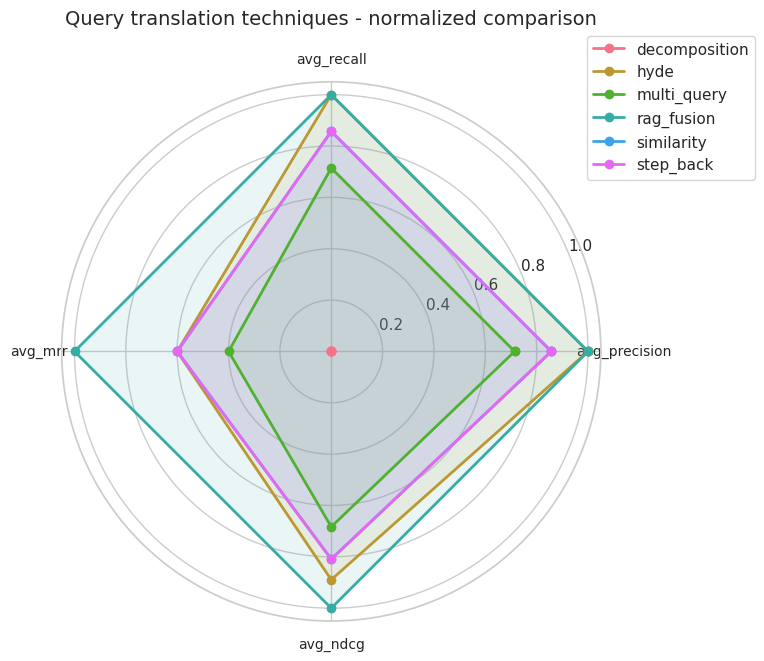

In [17]:
# Radar chart
radar_df = summary.reset_index().copy()
radar_metrics = ["avg_precision", "avg_recall", "avg_mrr", "avg_ndcg"]
radar_norm = radar_df.copy()
for col in radar_metrics:
    col_min, col_max = radar_norm[col].min(), radar_norm[col].max()
    if col_max > col_min:
        radar_norm[col] = (radar_norm[col] - col_min) / (col_max - col_min)
    else:
        radar_norm[col] = 0.5

display_radar_chart(
    radar_norm,
    metrics=radar_metrics,
    strategy_col="strategy",
    title="Query translation techniques - normalized comparison",
)

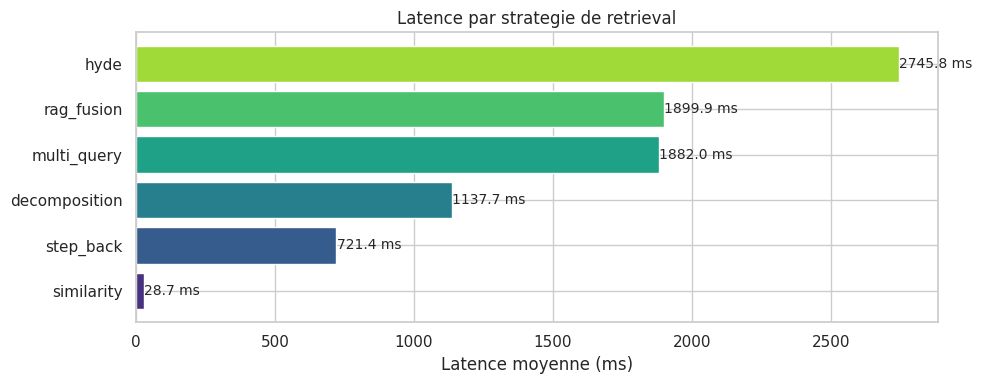


Latency vs MRR trade-off:


,avg_mrr,avg_llm_calls,avg_latency_s
strategy,,,
decomposition,0.6667,1.0,1.14
hyde,0.8667,1.0,2.75
multi_query,0.8000,1.0,1.88
rag_fusion,1.0000,1.0,1.90
similarity,0.8667,0.0,0.03
step_back,0.8667,1.0,0.72


In [18]:
# Latency comparison (log scale because of LLM overhead)
latency_df = summary.reset_index()[["strategy", "avg_latency_ms"]]
display_latency_comparison(latency_df)

print("\nLatency vs MRR trade-off:")
tradeoff = summary.reset_index()[["strategy", "avg_mrr", "avg_latency_ms", "avg_llm_calls"]].copy()
tradeoff["avg_latency_s"] = (tradeoff["avg_latency_ms"] / 1000).round(2)
display(tradeoff.set_index("strategy").drop(columns=["avg_latency_ms"]))

---
## 9. Analysis by Query Type

This benchmark has two categories: **methodology (3)** and **results (2)**.
We check whether query translation closes gaps for results-style questions.

Best per category (Precision@k):
- **methodology**: HyDE (0.9333)
- **results**: HyDE (0.6000)

In [19]:
cat_summary = (
    all_metrics_df.groupby(["category", "strategy"])
    .agg(
        avg_precision=("precision_at_k", "mean"),
        avg_mrr=("mrr", "mean"),
        avg_latency_ms=("latency_ms", "mean"),
    )
    .round(4)
    .reset_index()
)

print("Best strategy per category (Precision@k):")
best_per_cat = cat_summary.loc[
    cat_summary.groupby("category")["avg_precision"].idxmax()
][["category", "strategy", "avg_precision"]]
display(best_per_cat.set_index("category"))

print("\nBest strategy per category (MRR):")
best_mrr = cat_summary.loc[
    cat_summary.groupby("category")["avg_mrr"].idxmax()
][["category", "strategy", "avg_mrr"]]
display(best_mrr.set_index("category"))

Best strategy per category (Precision@k):


,strategy,avg_precision
category,,
methodology,hyde,0.9333
results,hyde,0.6000



Best strategy per category (MRR):


,strategy,avg_mrr
category,,
methodology,decomposition,1.0
results,rag_fusion,1.0


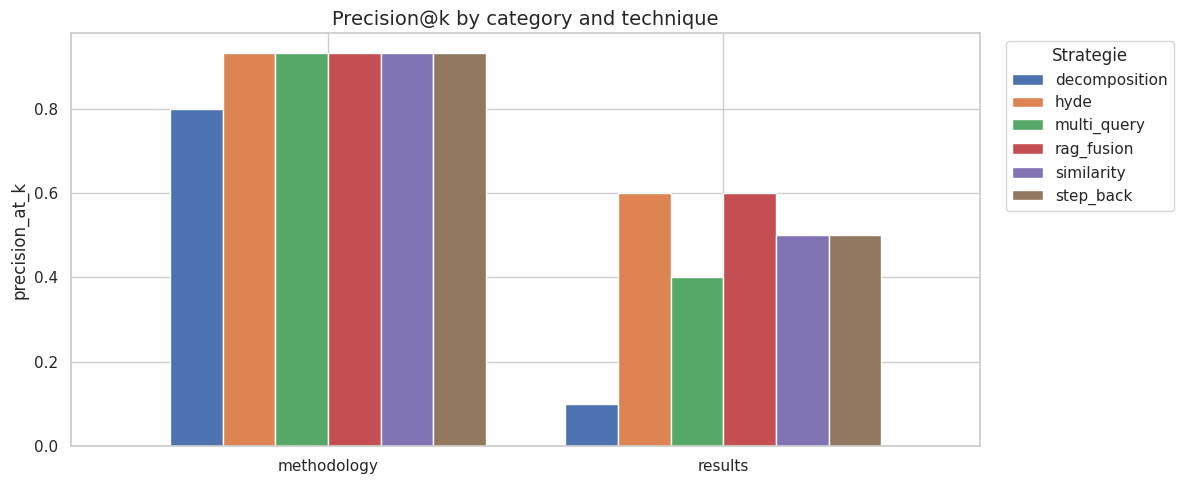

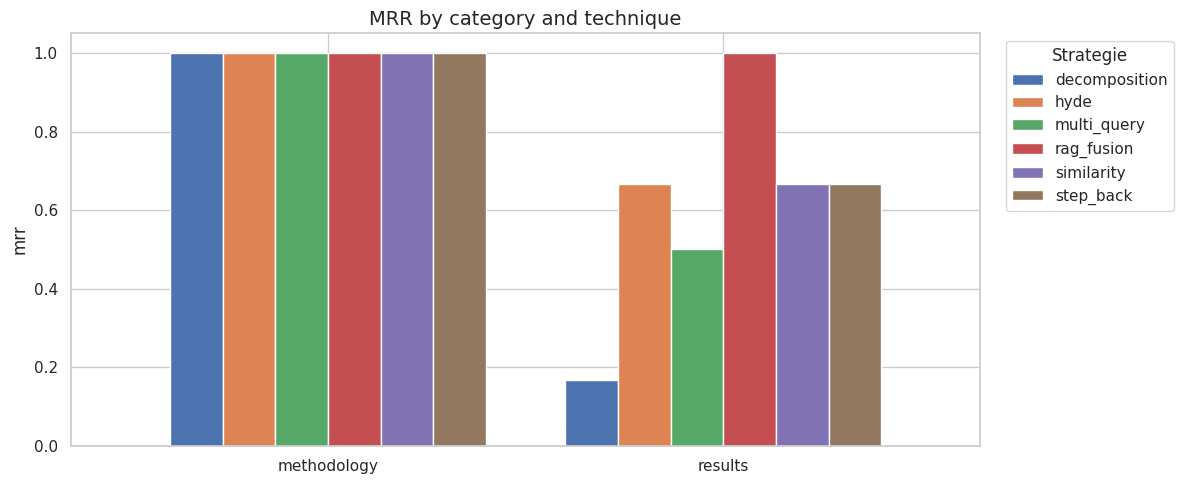

In [20]:
display_category_breakdown(
    all_metrics_df, metric="precision_at_k",
    title="Precision@k by category and technique",
)

display_category_breakdown(
    all_metrics_df, metric="mrr",
    title="MRR by category and technique",
)

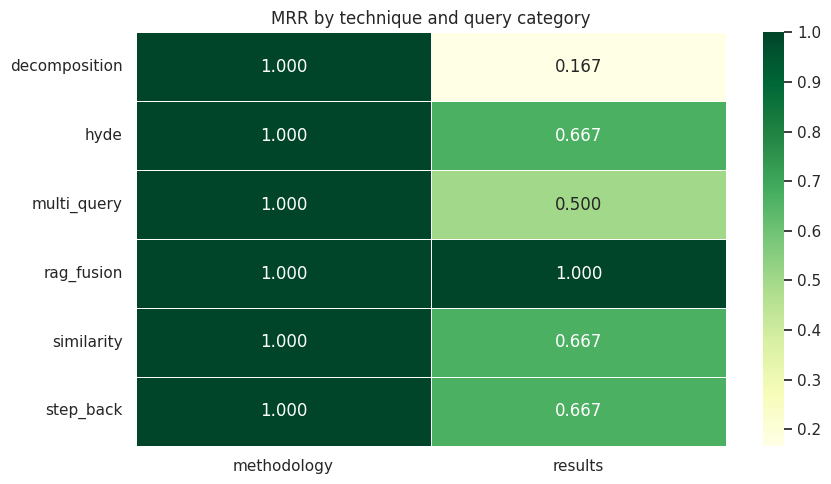

In [21]:
# Heatmap: MRR per strategy x category
pivot = cat_summary.pivot(index="strategy", columns="category", values="avg_mrr")

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot,
    annot=True, fmt=".3f",
    cmap="YlGn",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("MRR by technique and query category")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

---
## 10. Save Results

In [22]:
results_output = {
    "phase": 5,
    "corpus": {
        "num_raw_docs": len(docs),
        "num_cleaned_docs": len(cleaned_docs),
        "num_core_docs": len(core_docs),
        "num_chunks": len(chunks),
        "filter": "excluded /python/integrations/ pages",
        "chunking_strategy": "recursive",
        "chunk_size": 1000,
        "chunk_overlap": 200,
        "embedding_model": emb_info.model_id,
    },
    "benchmark": {
        "num_questions": len(questions),
        "k": K,
        "categories": {cat: len(qs) for cat, qs in sorted(categories.items())},
    },
    "llm": "mistral:7b",
    "techniques": {},
    "best_per_category": {},
}

for technique, group in all_metrics_df.groupby("strategy"):
    entry = {
        "avg_precision_at_k": round(float(group["precision_at_k"].mean()), 4),
        "avg_recall_at_k": round(float(group["recall_at_k"].mean()), 4),
        "avg_mrr": round(float(group["mrr"].mean()), 4),
        "avg_ndcg_at_k": round(float(group["ndcg_at_k"].mean()), 4),
        "avg_latency_ms": round(float(group["latency_ms"].mean()), 1),
        "avg_llm_calls": round(float(group["llm_calls"].mean()), 1),
        "per_category": {},
    }
    for cat, cat_group in group.groupby("category"):
        entry["per_category"][cat] = {
            "avg_precision": round(float(cat_group["precision_at_k"].mean()), 4),
            "avg_mrr": round(float(cat_group["mrr"].mean()), 4),
            "avg_latency_ms": round(float(cat_group["latency_ms"].mean()), 1),
        }
    results_output["techniques"][technique] = entry

for cat in sorted(categories.keys()):
    cat_data = cat_summary[cat_summary["category"] == cat]
    best = cat_data.loc[cat_data["avg_precision"].idxmax()]
    results_output["best_per_category"][cat] = best["strategy"]

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(exist_ok=True)
output_path = results_dir / "query_translation_comparison.json"

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results_output, f, indent=2, ensure_ascii=False)

print(f"Results saved to {output_path}")

Results saved to /home/hunganh/Code/Python/course_qa_assist/results/query_translation_comparison.json


---
## 11. Cleanup

In [23]:
try:
    client.delete_collection(COLLECTION)
    print(f"Collection '{COLLECTION}' deleted.")
except Exception:
    pass

print(f"Remaining collections: {[c.name for c in client.list_collections()]}")

Collection 'query_translation_eval' deleted.
Remaining collections: ['course_qa_naive']


---
## 12. Summary & Observations

### Results

| Technique | Precision@5 | MRR | nDCG@5 | Latency | LLM calls |
|---|---|---|---|---|---|
| Similarity (baseline) | 0.760 | 0.8667 | 0.7755 | **28.7 ms** | 0 |
| Multi-Query | 0.720 | 0.8000 | 0.7369 | 1882 ms | 1 |
| RAG Fusion | 0.800 | **1.0000** | **0.8339** | 1899.9 ms | 1 |
| HyDE | 0.800 | 0.8667 | 0.8000 | 2745.8 ms | 1 |
| Step-Back | 0.760 | 0.8667 | 0.7755 | 721.4 ms | 1 |
| Decomposition | 0.520 | 0.6667 | 0.5280 | 1137.7 ms | 1 |

### Key Takeaways

1. **RAG Fusion is best on quality** - it reaches MRR 1.0 and the highest nDCG, but costs ~1.9s per query.

2. **Similarity is a strong baseline** - it matches HyDE and Step-Back on MRR with ~29 ms latency.

3. **HyDE improves precision but not overall MRR** - strong methodology performance, but slower than RAG Fusion.

4. **Step-Back offers no quality gain here** - same metrics as baseline, with ~25x latency.

5. **Decomposition underperforms** - lowest precision and MRR on this benchmark.

### Cost-Benefit Assessment

| Scenario | Recommended technique |
|---|---|
| Latency-sensitive | Similarity (28.7 ms) |
| Best quality, any latency | RAG Fusion (MRR 1.0) |
| If you must use LLMs | HyDE or RAG Fusion (higher quality) |

### Evaluation Limitations

- The benchmark is small (5 questions), so differences may be noisy.
- Relevance uses partial URL matching on source metadata - same limitation as Phase 4.
- LLM quality heavily influences results; a stronger model may shift rankings.

### Next Step: Phase 6 - Basic RAG Chain

Build an end-to-end RAG pipeline: retrieval + prompt assembly + LLM generation.
Use RAG Fusion as the highest-quality option and evaluate full answer quality
with RAGAS-style metrics.